In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5)

In [10]:
#loading and aggregate to annual loss
df = pd.read_csv(
    r"C:\Users\ayush\Desktop\flood-cat-model-nfip\data\processed\nfip_claims_harris_tx_clean.csv"
)
annual = df.groupby("yearOfLoss").agg(
    claim_count = ("id", "count"),
    ground_up_loss = ("buildingDamageAmount", "sum"),
    actual_payout = ("netBuildingPaymentAmount", "sum"),
).reset_index()
annual

C:\Users\ayush\AppData\Local\Temp\ipykernel_22484\72510497.py:2: DtypeWarning: Columns (0: elevationCertificateIndicator, 1: eventDesignationNumber) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,yearOfLoss,claim_count,ground_up_loss,actual_payout
0,1978,105,4.111670e+05,3.680413e+05
1,1979,6251,5.521004e+07,5.006227e+07
2,1980,348,1.136706e+06,9.991136e+05
3,1981,3501,2.258821e+07,2.014610e+07
4,1982,245,9.867350e+05,8.663962e+05
5,1983,4435,7.359929e+07,5.965214e+07
6,1984,889,1.209880e+07,1.026053e+07
7,1985,380,2.835834e+06,2.425973e+06
8,1986,124,7.405080e+05,5.238790e+05
9,1987,331,1.281479e+07,2.182908e+06


In [11]:
#fill in zero-claim years (important, avoids biasing the average upward)

full_years = pd.DataFrame({
    "yearOfLoss": range(int(df["yearOfLoss"].min()), int(df["yearOfLoss"].max()) + 1)
})
annual_full = full_years.merge(annual, on="yearOfLoss", how="left")
annual_full[["claim_count", "ground_up_loss", "actual_payout"]] = (
    annual_full[["claim_count", "ground_up_loss", "actual_payout"]].fillna(0)
)
print(f"Years covered: {len(annual_full)}")
print(f"Years with zero recorded claims: {(annual_full['claim_count'] == 0).sum()}")
annual_full

Years covered: 49
Years with zero recorded claims: 0


,yearOfLoss,claim_count,ground_up_loss,actual_payout
0,1978,105,4.111670e+05,3.680413e+05
1,1979,6251,5.521004e+07,5.006227e+07
2,1980,348,1.136706e+06,9.991136e+05
3,1981,3501,2.258821e+07,2.014610e+07
4,1982,245,9.867350e+05,8.663962e+05
5,1983,4435,7.359929e+07,5.965214e+07
6,1984,889,1.209880e+07,1.026053e+07
7,1985,380,2.835834e+06,2.425973e+06
8,1986,124,7.405080e+05,5.238790e+05
9,1987,331,1.281479e+07,2.182908e+06


In [12]:
#define the primary ana;ysis window(2000-present, to avoid comparing eras with very different exposure)

START_YEAR = 2000
window = annual_full[annual_full["yearOfLoss"] >= START_YEAR].copy().reset_index(drop = True)
print(f"Primary analysis window: {START_YEAR}-{int(window['yearOfLoss'].max())} ({len(window)} years)")

Primary analysis window: 2000-2026 (27 years)


In [13]:
#rank years and compute empirical return periods (weibull plotting position)

window_sorted = window.sort_values("ground_up_loss", ascending=False).reset_index(drop=True)
n = len(window_sorted)
window_sorted["rank"] = window_sorted.index + 1
window_sorted["exceedance_probability"] = window_sorted["rank"] / (n + 1)
window_sorted["return_period_years"] = 1 / window_sorted["exceedance_probability"]
window_sorted[["yearOfLoss","ground_up_loss","claim_count","rank","exceedance_probability","return_period_years"]]

,yearOfLoss,ground_up_loss,claim_count,rank,exceedance_probability,return_period_years
0,2017,4.197034e+09,41604,1,0.035714,28.000000
1,2001,6.404803e+08,19415,2,0.071429,14.000000
2,2016,3.614974e+08,7091,3,0.107143,9.333333
3,2008,3.160526e+08,8680,4,0.142857,7.000000
4,2015,3.092082e+08,5951,5,0.178571,5.600000
5,2019,1.478896e+08,3246,6,0.214286,4.666667
6,2009,1.139509e+08,4198,7,0.250000,4.000000
7,2002,5.767206e+07,2488,8,0.285714,3.500000
8,2024,4.563878e+07,1162,9,0.321429,3.111111
9,2006,4.440739e+07,2098,10,0.357143,2.800000


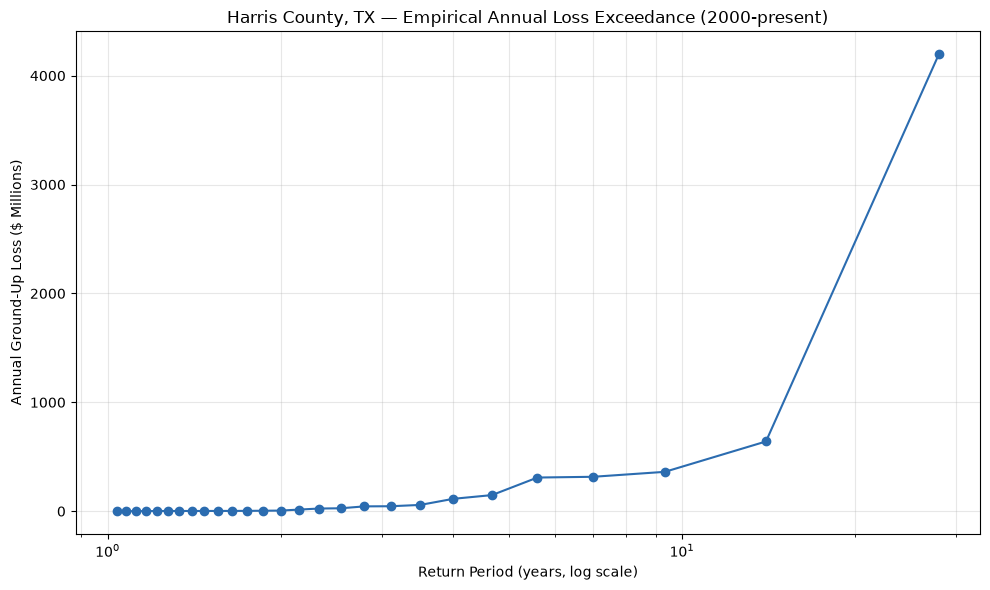

In [14]:
#plot the exceedance curve (a preview of your final EP curve):

plt.figure(figsize=(10, 6))
plt.plot(window_sorted["return_period_years"], window_sorted["ground_up_loss"] / 1e6,
         marker="o", color="#2b6cb0")
plt.xscale("log")
plt.xlabel("Return Period (years, log scale)")
plt.ylabel("Annual Ground-Up Loss ($ Millions)")
plt.title(f"Harris County, TX — Empirical Annual Loss Exceedance ({START_YEAR}-present)")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
#summary stats:
print(f"Average Annual Loss, ground-up ({START_YEAR}-present): ${window_sorted['ground_up_loss'].mean():,.0f}")
print(f"Median annual loss: ${window_sorted['ground_up_loss'].median():,.0f}")
worst = window_sorted.iloc[0]
print(f"Worst year: {int(worst['yearOfLoss'])} — ${worst['ground_up_loss']:,.0f} (~{worst['return_period_years']:.0f}-year event in this sample)")


Average Annual Loss, ground-up (2000-present): $234,493,169
Median annual loss: $5,656,186
Worst year: 2017 — $4,197,033,748 (~28-year event in this sample)


In [16]:
#save the table for later phases:

window_sorted.to_csv("annual_loss_table_harris_tx.csv", index=False)
print(f"Saved {len(window_sorted)} rows")

Saved 27 rows


In [17]:
without_2017 = window_sorted[window_sorted["yearOfLoss"] != 2017]
print(f"AAL including 2017: ${window_sorted['ground_up_loss'].mean():,.0f}")
print(f"AAL excluding 2017: ${without_2017['ground_up_loss'].mean():,.0f}")
print(f"2017 alone accounts for {window_sorted.loc[window_sorted['yearOfLoss']==2017,'ground_up_loss'].values[0] / window_sorted['ground_up_loss'].sum():.1%} of total losses across all 26 years")

AAL including 2017: $234,493,169
AAL excluding 2017: $82,087,762
2017 alone accounts for 66.3% of total losses across all 26 years
